In [1]:
import numpy as np
from matplotlib import pyplot as plt

import torch

import cv2

import os
from Dataset.data import DataPath
from Dataset.DataSetLoaders.ChessDataset import ChessDataset, GameDataset

import importlib
import ChessLens
importlib.reload(ChessLens);

In [9]:
# ds = ChessDataset(
#     config={
#         "img_size": (640,640)
#     }
# )
# ds = GameDataset(
#     config={
#         "img_size": (640,640)
#     }
# )
# img, y = ds[500]
# img, y = ds[340]
# img, y = ds[278]
# img, y = ds[57]

# img = ChessLens.ChessLensImage('/mnt/D/University/Thesis_Dataset/Temp/test.jpg', "cnn")
img = ChessLens.ChessLensImage('/mnt/D/University/Thesis_Dataset/Online Videos/resized/frame2.png', "cnn")
# img = ChessLens.ChessLensImage("/mnt/D/University/Thesis_Dataset/Temp/photo_84.jpg", "cnn")
# img = ChessLens.ChessLensImage("/mnt/D/University/Thesis_Dataset/Temp/video_2/video_14/testpic_88.jpg", "cnn")
# img = ChessLens.ChessLensImage("/mnt/D/University/Thesis_Dataset/Dataset/Images/image_137.png", "cnn")
# img = ChessLens.ChessLensImage(img, "cnn")
# y["image_path"]

In [10]:
quad, conf = img.detect_board()
# img.recognize_clock()
img.board_detection = torch.tensor([
    [249,484],
    [381,481],
    [437,631],
    [200,639],
])
img.recognize_pieces()
img.save_fen_image()

In [11]:
img.board_detection

tensor([[249, 484],
        [381, 481],
        [437, 631],
        [200, 639]])

'rp4PR/1p4P1/bp1p1NP1/k1pn3K/5BBK/bq3P2/1p6/rp4PR'

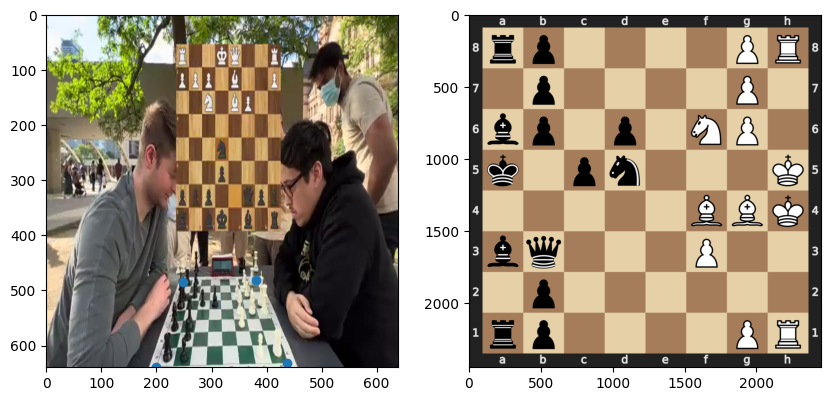

In [12]:
plt.figure(figsize=(10, 10))

plt.subplot(1,2,1)
plt.imshow(img.img.permute(1,2,0));
plt.scatter(img.board_detection[:,0], img.board_detection[:,1]);
plt.subplot(1,2,2)
plt.imshow(plt.imread("out_fen.png"));
img.fen

array([[    -1.2944,    -0.40217,      513.82],
       [  -0.025701,     -1.9232,      952.71],
       [ 3.5893e-05,   -0.003521,           1]])

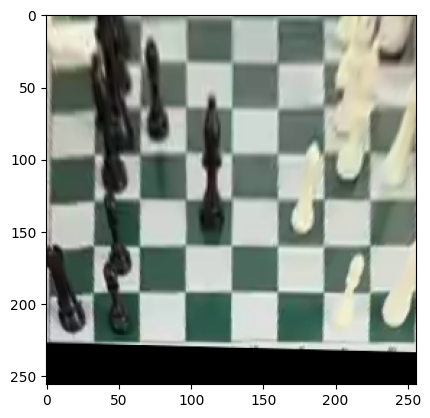

In [6]:
warpped_img, M = img.warp()
plt.imshow(warpped_img);
M